# NB-00 — Exploratory Data Analysis Overview
## The Peacekeepers' Arms Race: Testing the Stability–Instability Paradox

**Purpose:** This notebook documents all nine datasets used in the study — where they come from, how they were cleaned, and what the master analytical panel looks like. It is structured as a walkthrough for a lecturer unfamiliar with the pipeline.

---

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from IPython.display import display

from src.config import CLEAN_DIR, FIGURES_DIR

EDA_DIR = FIGURES_DIR / 'eda'
EDA_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 50)

PROVIDER_COLORS = {
    'UCDP':       '#2196F3',
    'SIPRI':      '#FF5722',
    'World Bank': '#4CAF50',
    'V-Dem':      '#9C27B0',
    'CoW':        '#FF9800',
}

REGION_PAL = {
    'Africa':      '#E74C3C',
    'Americas':    '#3498DB',
    'Asia':        '#2ECC71',
    'Europe':      '#9B59B6',
    'Middle East': '#E67E22',
    'Oceania':     '#1ABC9C',
    'Post-Soviet': '#95A5A6',
    'Other':       '#BDC3C7',
}

def _load(fname):
    """Load a clean parquet with a clear error if missing."""
    path = CLEAN_DIR / fname
    try:
        df = pd.read_parquet(path)
        print(f'  loaded {fname}  {df.shape}')
        return df
    except FileNotFoundError:
        print(f'  MISSING: {path}  --  run NB01-NB03 first')
        return None

print('Setup complete.')
print(f'Clean dir  : {CLEAN_DIR}')
print(f'EDA figures: {EDA_DIR}')


Setup complete.
Clean dir  : D:\post graduate\assignments and projects\sem 3\BDA\PeaceMakers' Arms Race\version 2\data\clean
EDA figures: D:\post graduate\assignments and projects\sem 3\BDA\PeaceMakers' Arms Race\version 2\figures\eda


---
## Section 1 — Project Overview

### Research Question

This study tests the **Stability-Instability Paradox** (SIP): the theory that nuclear deterrence between adversaries stabilises full-scale war (because the threat of nuclear escalation is too great) but simultaneously *enables* limited proxy wars and conventional skirmishes below the nuclear threshold (because neither side can escalate without risking annihilation). If the paradox holds, we should see nuclear states fighting *more* small-scale conflicts abroad while fighting *fewer* full-scale wars at home.

### Three Research Questions

| RQ | Question | Method |
|----|----------|--------|
| **RQ1** | Do countries with higher military spending and arms imports fight more extraterritorial small wars? | Panel regression (country-year, 1989–2024) |
| **RQ2** | Do arms transfers to a country predict an increase in conflict events in the following months? | Time-series lead-lag analysis (monthly GED events) |
| **RQ3** | Can countries be clustered by their conflict profiles and military posture? Do nuclear/allied states form distinct clusters? | Dimensionality reduction + k-means clustering (cross-section) |

### The Nine Datasets

The study integrates nine public datasets from five providers. Together they give a 79-year panel (1946–2024) of conflict events, military spending, arms transfers, economic controls, democracy scores, and military capabilities for up to 192 countries.

In [2]:
sources = pd.DataFrame({
    'Source': [
        'UCDP ACD', 'UCDP GED', 'UCDP BRD', 'UCDP Dyadic',
        'SIPRI MILEX', 'SIPRI TIV Register',
        'World Bank WDI', 'V-Dem', 'CoW CINC',
    ],
    'Provider': [
        'Uppsala Conflict Data Program', 'Uppsala', 'Uppsala', 'Uppsala',
        'Stockholm International Peace Research Institute', 'SIPRI',
        'World Bank', 'V-Dem Institute', 'Correlates of War',
    ],
    'Granularity': [
        'Conflict-year', 'Event (geocoded)', 'Conflict-year', 'Dyad-year',
        'Country-year', 'Transfer-year',
        'Country-year', 'Country-year', 'Country-year',
    ],
    'Years': [
        '1946-2024', '1989-2024', '1989-2024', '1946-2024',
        '1949-2025', '1950-2025',
        '1960-2024', '1946-2024', '1816-2016',
    ],
    'Role in analysis': [
        'Conflict counts at location (acd_* cols)',
        'Monthly events for RQ2 outcome variable',
        'Battle deaths at conflict location (brd_* cols)',
        'Participation panel + is_extraterritorial flag (part_* cols)',
        'Military expenditure treatment variable',
        'Arms transfer treatment variable (TIV)',
        'GDP, population, per-capita income controls (wb_* cols)',
        'Electoral democracy index (vdem_v2x_polyarchy)',
        'CINC military capability index (cutoff 2016)',
    ],
})

display(sources.set_index('Source').style.set_table_styles([
    {'selector': 'th', 'props': [('font-weight', 'bold'), ('background', '#f0f0f0')]},
    {'selector': 'td', 'props': [('text-align', 'left'), ('white-space', 'normal')]},
]))


,Provider,Granularity,Years,Role in analysis
Source,,,,
UCDP ACD,Uppsala Conflict Data Program,Conflict-year,1946-2024,Conflict counts at location (acd_* cols)
UCDP GED,Uppsala,Event (geocoded),1989-2024,Monthly events for RQ2 outcome variable
UCDP BRD,Uppsala,Conflict-year,1989-2024,Battle deaths at conflict location (brd_* cols)
UCDP Dyadic,Uppsala,Dyad-year,1946-2024,Participation panel + is_extraterritorial flag (part_* cols)
SIPRI MILEX,Stockholm International Peace Research Institute,Country-year,1949-2025,Military expenditure treatment variable
SIPRI TIV Register,SIPRI,Transfer-year,1950-2025,Arms transfer treatment variable (TIV)
World Bank WDI,World Bank,Country-year,1960-2024,"GDP, population, per-capita income controls (wb_* cols)"
V-Dem,V-Dem Institute,Country-year,1946-2024,Electoral democracy index (vdem_v2x_polyarchy)
CoW CINC,Correlates of War,Country-year,1816-2016,CINC military capability index (cutoff 2016)


---
## Section 2 — Raw Dataset Shapes (Before Cleaning)

The nine datasets vary enormously in scale. The UCDP Georeferenced Event Dataset (GED) alone has 385,918 rows (one per geocoded conflict event), while the UCDP Battle-Related Deaths dataset has just 1,586 rows (one per conflict-year dyad). A log scale is necessary to show all sources on the same axis.

The colour coding groups datasets by provider: UCDP (blue), SIPRI (orange), World Bank (green), V-Dem (purple), Correlates of War (amber). Understanding which source each column in the master panel comes from is important for interpreting coverage patterns — a CoW CINC variable will be NaN after 2016 not because of a pipeline bug, but because the source dataset stops there.

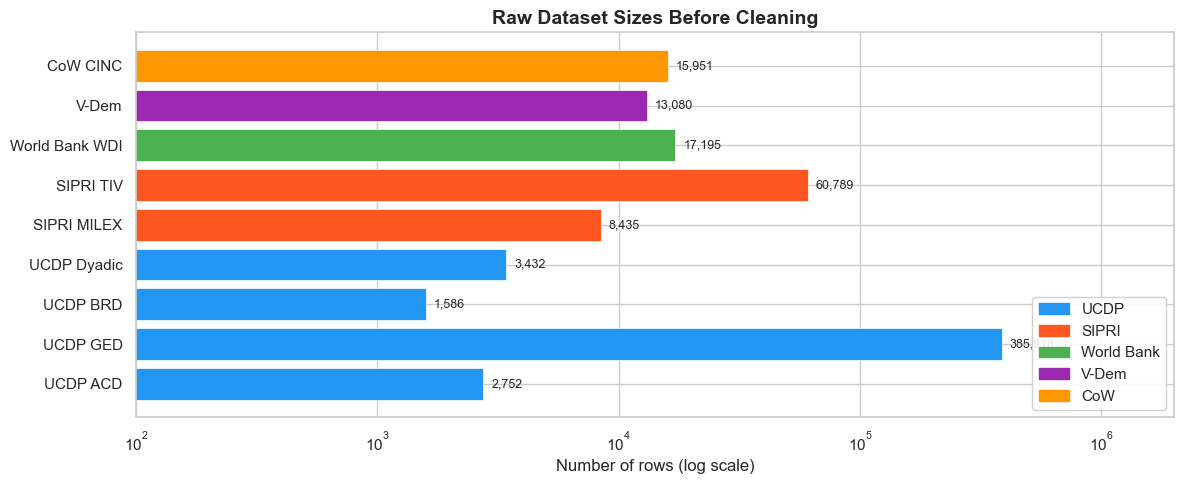

Figure saved to D:\post graduate\assignments and projects\sem 3\BDA\PeaceMakers' Arms Race\version 2\figures\eda\sec2_raw_row_counts.png


In [3]:
raw_counts = [
    ('UCDP ACD',       'UCDP',         2_752),
    ('UCDP GED',       'UCDP',       385_918),
    ('UCDP BRD',       'UCDP',         1_586),
    ('UCDP Dyadic',    'UCDP',         3_432),
    ('SIPRI MILEX',    'SIPRI',        8_435),
    ('SIPRI TIV',      'SIPRI',       60_789),
    ('World Bank WDI', 'World Bank',  17_195),
    ('V-Dem',          'V-Dem',       13_080),
    ('CoW CINC',       'CoW',         15_951),
]

labels    = [r[0] for r in raw_counts]
providers = [r[1] for r in raw_counts]
rows      = [r[2] for r in raw_counts]
colors    = [PROVIDER_COLORS[p] for p in providers]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(labels, rows, color=colors, edgecolor='white', linewidth=0.5)
ax.set_xscale('log')
ax.set_xlabel('Number of rows (log scale)', fontsize=12)
ax.set_title('Raw Dataset Sizes Before Cleaning', fontsize=14, fontweight='bold')

for bar, count in zip(bars, rows):
    ax.text(bar.get_width() * 1.08, bar.get_y() + bar.get_height() / 2,
            f'{count:,}', va='center', fontsize=9)

legend_patches = [
    mpatches.Patch(color=c, label=p) for p, c in PROVIDER_COLORS.items()
]
ax.legend(handles=legend_patches, loc='lower right', framealpha=0.9)
ax.set_xlim(100, 2_000_000)
fig.tight_layout()
fig.savefig(EDA_DIR / 'sec2_raw_row_counts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to', EDA_DIR / 'sec2_raw_row_counts.png')


---
## Section 3 — How Each Dataset Changed After Cleaning (NB-02)

### Why ISO3 standardisation is necessary

Nine datasets from five different providers use inconsistent country names. UCDP uses 'Syrian Arab Republic', SIPRI uses 'Syria', the World Bank uses 'Syrian Arab Republic', and V-Dem uses its own three-letter codes. Without a common key, no cross-source joins are possible.

The cleaning notebook (NB-02) runs every country name through an `ISO3Resolver` — a three-tier lookup that tries dataset-specific overrides first, then project-wide `GLOBAL_OVERRIDES` (handling 'USSR'→'RUS', 'Yugoslavia'→'SRB', historical parenthetical names like 'Russia (Soviet Union)'→'RUS', etc.), then pycountry exact-field lookups. Names that cannot be matched (non-state actors like 'ABSDF', pre-1870 micro-states like 'Bavaria') are dropped and logged to `_unmatched_audit.csv` for review.

The table below summarises what happened to each dataset. **Note for UCDP ACD:** the row count appears to *increase* because multi-country conflict entries ('India, Pakistan') are exploded into one row per country — 2,752 input rows become 2,917 after the explode, with 2,914 resolving to a valid ISO3.

In [4]:
cleaning = pd.DataFrame({
    'Source': [
        'UCDP ACD', 'UCDP GED', 'UCDP BRD', 'UCDP Dyadic',
        'SIPRI MILEX', 'SIPRI TIV', 'World Bank WDI', 'V-Dem', 'CoW CINC',
    ],
    'Raw rows': [2752, 385918, 1586, 3432, 8435, 60789, 17195, 13080, 15951],
    'ISO3-matched': [2914, 385918, 1536, 3279, 8362, 59897, 13035, 12787, 15166],
    'Match %': [99.9, 100.0, 96.8, 95.5, 100.0, 99.6, 100.0, 100.0, 100.0],
    'Dropped / delta': ['*+165 added', 0, 0, 0, 73, 624, 4160, 293, 785],
    'Reason': [
        '*Multi-country explode adds rows; 3 unresolvable',
        'All resolved',
        'Multi-country location_inc (e.g. India-Pakistan)',
        'Non-state actors (ABSDF, PKK, FARC) unresolvable',
        'Suppressed values + EU aggregate dropped',
        'Non-state recipients (asterisk notation)',
        'Regional aggregates (World, High income, East Asia...)',
        '214 state-transition duplicates + 79 unresolvable codes',
        'Pre-1870 German/Italian micro-states (Bavaria, Hanover...)',
    ],
})

def _match_color(val):
    if not isinstance(val, float):
        return ''
    if val < 95:
        return 'background-color: #f4cccc; color: #7f0000'
    if val < 99:
        return 'background-color: #fce8b2; color: #7f4f00'
    return 'background-color: #d9ead3; color: #1b4f19'

display(
    cleaning.set_index('Source')
    .style
    .map(_match_color, subset=['Match %'])
    .format({'Raw rows': '{:,}', 'ISO3-matched': '{:,}', 'Match %': '{:.1f}%'})
    .set_table_styles([
        {'selector': 'th', 'props': [('background', '#f0f0f0'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('text-align', 'left')]},
    ])
)


,Raw rows,ISO3-matched,Match %,Dropped / delta,Reason
Source,,,,,
UCDP ACD,"2,752","2,914",99.9%,*+165 added,*Multi-country explode adds rows; 3 unresolvable
UCDP GED,"385,918","385,918",100.0%,0,All resolved
UCDP BRD,"1,586","1,536",96.8%,0,Multi-country location_inc (e.g. India-Pakistan)
UCDP Dyadic,"3,432","3,279",95.5%,0,"Non-state actors (ABSDF, PKK, FARC) unresolvable"
SIPRI MILEX,"8,435","8,362",100.0%,73,Suppressed values + EU aggregate dropped
SIPRI TIV,"60,789","59,897",99.6%,624,Non-state recipients (asterisk notation)
World Bank WDI,"17,195","13,035",100.0%,4160,"Regional aggregates (World, High income, East Asia...)"
V-Dem,"13,080","12,787",100.0%,293,214 state-transition duplicates + 79 unresolvable codes
CoW CINC,"15,951","15,166",100.0%,785,"Pre-1870 German/Italian micro-states (Bavaria, Hanover...)"


---
## Section 4 — Key Cleaning Decisions

Three design choices in NB-02 have a large impact on downstream analysis. Each is documented here with a concrete example so that a reviewer can understand the reasoning without reading the full cleaning code.

In [5]:
# ── 4.1  Zero vs NaN distinction ──────────────────────────────────────────────
# The wrong fill policy silently biases regression coefficients. Two mutually
# exclusive lists of columns are defined in NB-02 with explicit rationale.

print('=== Zero-fill vs NaN-preserve distinction ===\n')

example = pd.DataFrame({
    'iso3':  ['CRI', 'CRI', 'USA', 'SOM', 'SOM'],
    'year':  [2000,  2001,  2000,  2000,  2001],
    'part_n_conflicts': [0, 0, 3, 2, 1],
    'sipri_milex_usd':  [0.0, 0.0, 640_000.0, float('nan'), float('nan')],
})

print('Example rows (CRI = Costa Rica, USA, SOM = Somalia):\n')
display(example.set_index(['iso3', 'year']).style.highlight_null(color='#ffe0e0'))

print()
print('ZERO-FILL columns  (no record = zero events, not missing data)')
zero_cols = [
    'acd_n_conflicts   — no UCDP location record means zero conflicts at that site',
    'part_n_extraterritorial — no dyadic record means no foreign intervention',
    'ged_n_events      — no GED event means zero georeferenced events',
    'tiv_imports_total — no SIPRI TIV record means zero arms imported',
    'brd_deaths_best   — no BRD record means zero battle deaths logged',
]
for c in zero_cols:
    print(f'  [0]  {c}')

print()
print('NaN-PRESERVE columns  (no record = unobserved or suppressed, NOT zero)')
nan_cols = [
    'sipri_milex_const2024_usd — NaN = data suppressed; 0 = genuine zero (e.g. Costa Rica)',
    'wb_gdp_usd                — NaN = WDI did not report for that year',
    'vdem_v2x_polyarchy        — NaN = outside V-Dem observation window',
    'cow_cinc                  — NaN for all years > 2016 (NMC v6.0 ends there)',
]
for c in nan_cols:
    print(f'  [?]  {c}')

print()
print('Costa Rica has milex=0 (constitutional ban on standing army since 1948).')
print('Somalia has milex=NaN — SIPRI suppresses the data. Imputing 0 would be wrong.')


=== Zero-fill vs NaN-preserve distinction ===

Example rows (CRI = Costa Rica, USA, SOM = Somalia):




ZERO-FILL columns  (no record = zero events, not missing data)
  [0]  acd_n_conflicts   — no UCDP location record means zero conflicts at that site
  [0]  part_n_extraterritorial — no dyadic record means no foreign intervention
  [0]  ged_n_events      — no GED event means zero georeferenced events
  [0]  tiv_imports_total — no SIPRI TIV record means zero arms imported
  [0]  brd_deaths_best   — no BRD record means zero battle deaths logged

NaN-PRESERVE columns  (no record = unobserved or suppressed, NOT zero)
  [?]  sipri_milex_const2024_usd — NaN = data suppressed; 0 = genuine zero (e.g. Costa Rica)
  [?]  wb_gdp_usd                — NaN = WDI did not report for that year
  [?]  vdem_v2x_polyarchy        — NaN = outside V-Dem observation window
  [?]  cow_cinc                  — NaN for all years > 2016 (NMC v6.0 ends there)

Costa Rica has milex=0 (constitutional ban on standing army since 1948).
Somalia has milex=NaN — SIPRI suppresses the data. Imputing 0 would be wrong.


In [6]:
# ── 4.2  Historical state succession mappings ──────────────────────────────────
# The panel spans 1946-2024. Many states ceased to exist within that window.
# To include Cold War era data without creating phantom entities, each predecessor
# is mapped to a single modern successor ISO3 following principled rules documented
# in GLOBAL_OVERRIDES (src/iso3.py).

state_mappings = pd.DataFrame({
    'Historical entity': [
        'Soviet Union / USSR',
        'Yugoslavia / SFR Yugoslavia',
        'Czechoslovakia',
        'West Germany + East Germany',
        'North Yemen + South Yemen',
        'North Vietnam + South Vietnam',
    ],
    'ISO3': ['RUS', 'SRB', 'CZE', 'DEU', 'YEM', 'VNM'],
    'Modern name': [
        'Russia', 'Serbia', 'Czech Republic',
        'Germany', 'Yemen', 'Vietnam',
    ],
    'Treatment': [
        'UN-seat successor; nuclear weapons succession (1991)',
        'UN-seat successor by Badinter Commission (1992)',
        'Larger economy/population; Slovakia coded as SVK separately',
        'Reunification 1990: milper/milex/CINC summed; GDP summed',
        'Unification 1990: predecessors merged into single YEM entity',
        'Reunification 1975: predecessors merged into unified VNM',
    ],
    'Cold-War years affected': [
        '1946-1991 (45 yrs)', '1946-1991 (45 yrs)',
        '1946-1992 (46 yrs)', '1946-1990 (44 yrs)',
        '1967-1990 (23 yrs)', '1946-1975 (29 yrs)',
    ],
})

print('Historical state succession mappings used in GLOBAL_OVERRIDES:\n')
display(state_mappings.set_index('Historical entity').style.set_table_styles([
    {'selector': 'th', 'props': [('background', '#f0f0f0'), ('font-weight', 'bold')]},
    {'selector': 'td', 'props': [('text-align', 'left'), ('white-space', 'normal')]},
]))
print()
print('Why this matters for a 1946-2024 panel:')
print('  Without these mappings, the Soviet Union would have 45 years of missing data')
print('  for every variable, and the panel would systematically undercount Cold-War-era')
print('  conflict participation by Russia, military spending by Germany, etc.')


Historical state succession mappings used in GLOBAL_OVERRIDES:



,ISO3,Modern name,Treatment,Cold-War years affected
Historical entity,,,,
Soviet Union / USSR,RUS,Russia,UN-seat successor; nuclear weapons succession (1991),1946-1991 (45 yrs)
Yugoslavia / SFR Yugoslavia,SRB,Serbia,UN-seat successor by Badinter Commission (1992),1946-1991 (45 yrs)
Czechoslovakia,CZE,Czech Republic,Larger economy/population; Slovakia coded as SVK separately,1946-1992 (46 yrs)
West Germany + East Germany,DEU,Germany,Reunification 1990: milper/milex/CINC summed; GDP summed,1946-1990 (44 yrs)
North Yemen + South Yemen,YEM,Yemen,Unification 1990: predecessors merged into single YEM entity,1967-1990 (23 yrs)
North Vietnam + South Vietnam,VNM,Vietnam,Reunification 1975: predecessors merged into unified VNM,1946-1975 (29 yrs)



Why this matters for a 1946-2024 panel:
  Without these mappings, the Soviet Union would have 45 years of missing data
  for every variable, and the panel would systematically undercount Cold-War-era
  conflict participation by Russia, military spending by Germany, etc.


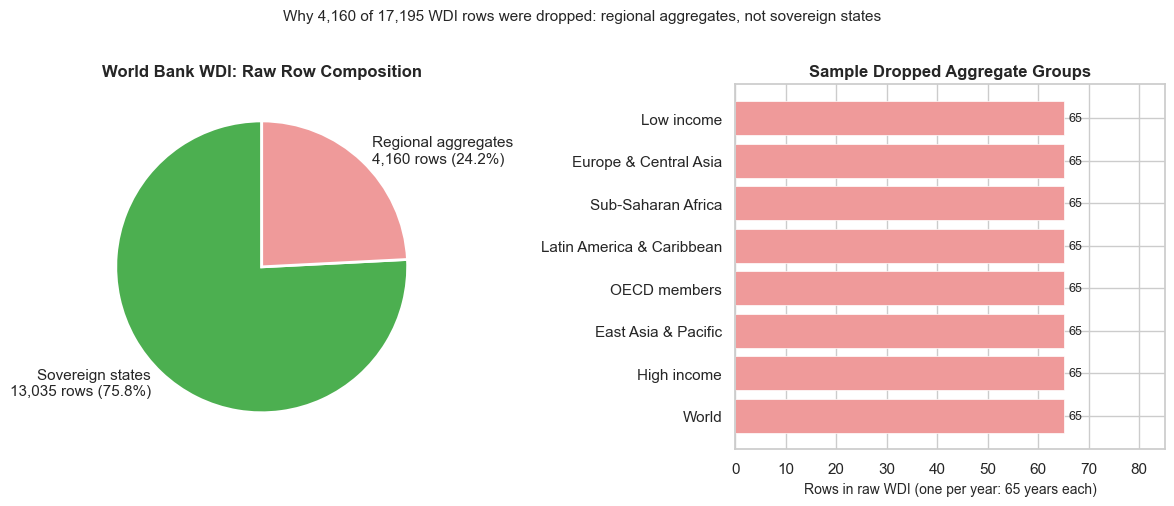

Figure saved to D:\post graduate\assignments and projects\sem 3\BDA\PeaceMakers' Arms Race\version 2\figures\eda\sec4_wdi_aggregate_drop.png


In [7]:
# ── 4.3  WDI regional aggregate drop ──────────────────────────────────────────
# The World Bank WDI download bundles sovereign-state rows with 64 regional
# and income-group aggregates ("World", "High income", "East Asia & Pacific" etc.).
# Aggregates fail ISO3 resolution and are automatically excluded — they have no
# conflict history, no democracy score, and no military spending equivalent.

sovereign  = 13_035
aggregates = 4_160
total_wdi  = sovereign + aggregates

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: pie chart
axes[0].pie(
    [sovereign, aggregates],
    labels=[
        f'Sovereign states\n{sovereign:,} rows ({100*sovereign/total_wdi:.1f}%)',
        f'Regional aggregates\n{aggregates:,} rows ({100*aggregates/total_wdi:.1f}%)',
    ],
    colors=['#4CAF50', '#EF9A9A'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11},
)
axes[0].set_title('World Bank WDI: Raw Row Composition', fontsize=12, fontweight='bold')

# Right: example aggregate names that were dropped
agg_names = [
    'World', 'High income', 'East Asia & Pacific',
    'OECD members', 'Latin America & Caribbean',
    'Sub-Saharan Africa', 'Europe & Central Asia',
    'Low income',
]
axes[1].barh(agg_names, [65]*8, color='#EF9A9A', edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('Rows in raw WDI (one per year: 65 years each)', fontsize=10)
axes[1].set_title('Sample Dropped Aggregate Groups', fontsize=12, fontweight='bold')
axes[1].set_xlim(0, 85)
for i in range(len(agg_names)):
    axes[1].text(66, i, '65', va='center', fontsize=9)

fig.suptitle(
    'Why 4,160 of 17,195 WDI rows were dropped: regional aggregates, not sovereign states',
    fontsize=11, y=1.01,
)
fig.tight_layout()
fig.savefig(EDA_DIR / 'sec4_wdi_aggregate_drop.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to', EDA_DIR / 'sec4_wdi_aggregate_drop.png')


---
## Section 5 — Master Panel Overview

After all cleaning and merging, the result is a **balanced panel** of 192 countries × 79 years (1946–2024) = 15,168 country-year rows. Every (iso3, year) combination exists — countries with zero conflict events appear explicitly with zero counts rather than being absent from the data. This matters for regression: treating absent rows as missing data would bias conflict-frequency estimates upward (the zeros are just as informative as the positive counts).

The panel has 56 columns grouped by source. Coverage is uneven: UCDP conflict variables and V-Dem democracy scores span 1946–2024 (or 1989–2024 for GED), while World Bank GDP data starts in 1960 and CoW CINC ends in 2016. These gaps are structural limitations of the source data, not pipeline errors.

In [8]:
master = _load('master_panel.parquet')
if master is None:
    raise RuntimeError('master_panel.parquet not found — run NB03 first.')

print(f'\nMaster panel: {master.shape}')
print(f'Countries:    {master["iso3"].nunique()} unique ISO3 codes')
print(f'Years:        {int(master["year"].min())}-{int(master["year"].max())} ({master["year"].nunique()} years)')
print(f'Balanced:     {master["iso3"].nunique()} x {master["year"].nunique()} = {len(master):,} rows')
print()

col_groups = {
    'Panel spine':         ['iso3', 'year', 'region'],
    'UCDP ACD (location)': [c for c in master.columns if c.startswith('acd_')],
    'UCDP participation':  [c for c in master.columns if c.startswith('part_')],
    'UCDP BRD (deaths)':   [c for c in master.columns if c.startswith('brd_')],
    'UCDP GED (events)':   [c for c in master.columns if c.startswith('ged_')],
    'SIPRI MILEX':         [c for c in master.columns if 'milex' in c and not c.startswith('log')],
    'SIPRI TIV':           [c for c in master.columns if c.startswith('tiv_')],
    'World Bank WDI':      [c for c in master.columns if c.startswith('wb_')],
    'V-Dem':               [c for c in master.columns if c.startswith('vdem_')],
    'CoW CINC':            [c for c in master.columns if c.startswith('cow_')],
    'Derived':             [c for c in master.columns if c.startswith('log_') or
                            c in ('war_minor_ratio', 'milex_pct_gdp', 'extraterritorial_share',
                                  'tiv_imports_5yr_sum', 'milex_5yr_mean', 'has_military',
                                  'era_cold_war', 'era_post_cw', 'era_post_911')],
}

for group, cols in col_groups.items():
    existing = [c for c in cols if c in master.columns]
    if existing:
        cols_str = ', '.join(existing)
        print(f'{group:>28}  ({len(existing):>2} cols): {cols_str}')


  loaded master_panel.parquet  (15168, 61)

Master panel: (15168, 61)
Countries:    192 unique ISO3 codes
Years:        1946-2024 (79 years)
Balanced:     192 x 79 = 15,168 rows

                 Panel spine  ( 3 cols): iso3, year, region
         UCDP ACD (location)  ( 7 cols): acd_n_conflicts, acd_n_war, acd_n_minor, acd_n_interstate, acd_n_intrastate, acd_n_extrasystemic, acd_n_internationalised
          UCDP participation  ( 8 cols): part_n_conflicts, part_n_interstate, part_n_intrastate, part_n_internationalised, part_n_extrasystemic, part_n_war, part_n_minor, part_n_extraterritorial
           UCDP BRD (deaths)  ( 3 cols): brd_deaths_best, brd_deaths_low, brd_deaths_high
           UCDP GED (events)  ( 2 cols): ged_n_events, ged_deaths_total
                 SIPRI MILEX  ( 5 cols): sipri_milex_const2024_usd, cow_milex, milex_pct_gdp, milex_5yr_mean, mts_milex
                   SIPRI TIV  (14 cols): tiv_imports_total, tiv_cat_air_defence_systems, tiv_cat_aircraft, tiv_cat_armour

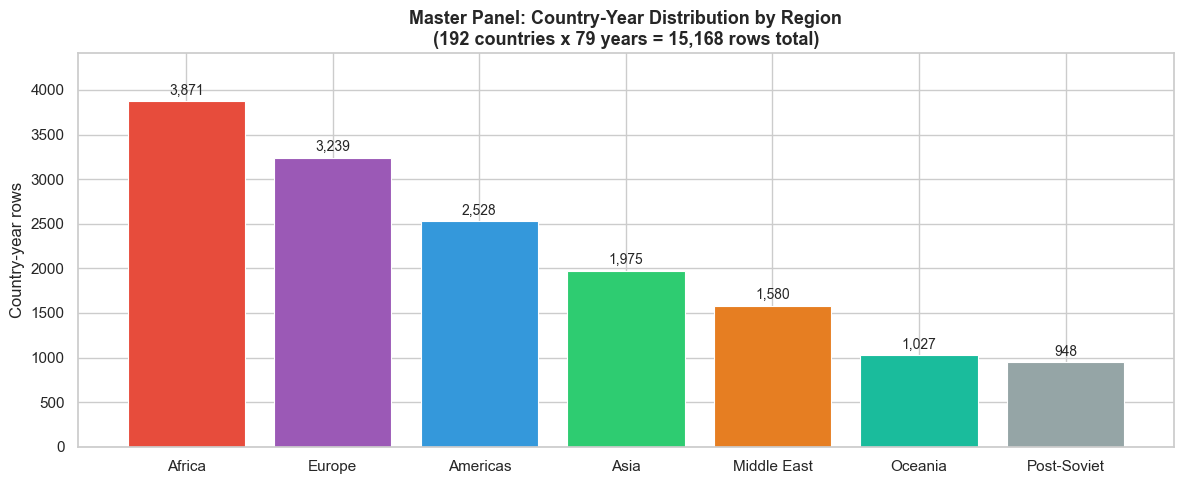

Figure saved to D:\post graduate\assignments and projects\sem 3\BDA\PeaceMakers' Arms Race\version 2\figures\eda\sec5_region_distribution.png


In [9]:
# Region distribution is hardcoded from the master panel region value_counts,
# confirmed by the NB03 Section 5 output.
region_counts = pd.Series({
    'Africa':      3871,
    'Europe':      3239,
    'Americas':    2528,
    'Asia':        1975,
    'Middle East': 1580,
    'Oceania':     1027,
    'Post-Soviet':  948,
}, name='Country-year rows')

fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = [REGION_PAL.get(r, '#BDC3C7') for r in region_counts.index]
bars = ax.bar(region_counts.index, region_counts.values,
              color=bar_colors, edgecolor='white', linewidth=0.8)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 40,
            f'{int(bar.get_height()):,}',
            ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Country-year rows', fontsize=12)
ax.set_title(
    'Master Panel: Country-Year Distribution by Region\n'
    '(192 countries x 79 years = 15,168 rows total)',
    fontsize=13, fontweight='bold',
)
ax.set_ylim(0, region_counts.max() * 1.14)
fig.tight_layout()
fig.savefig(EDA_DIR / 'sec5_region_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to', EDA_DIR / 'sec5_region_distribution.png')


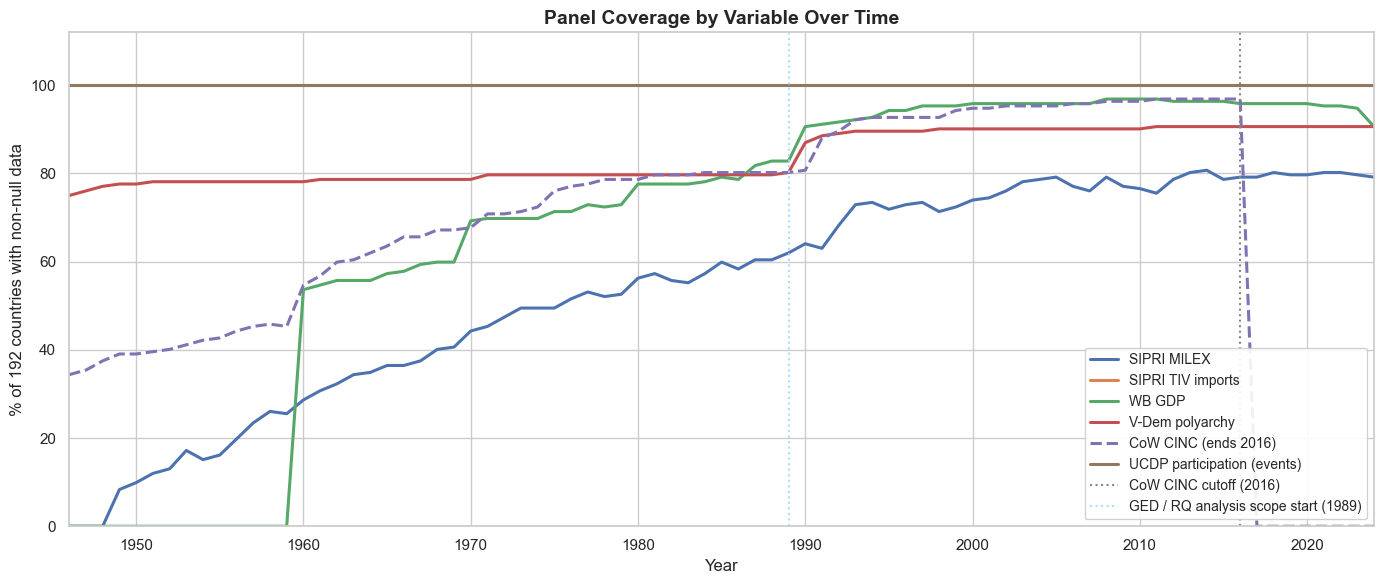

Figure saved to D:\post graduate\assignments and projects\sem 3\BDA\PeaceMakers' Arms Race\version 2\figures\eda\sec5_panel_coverage.png


In [10]:
# ── Panel Coverage by Variable Over Time ─────────────────────────────────────
# The balance report CSV (from NB03) records how many of the 192 countries have
# non-null values for each key variable in each year. This reveals structural
# gaps: World Bank GDP starts in 1960, CoW CINC ends in 2016.

KEY_VARS = [
    'sipri_milex_const2024_usd',
    'tiv_imports_total',
    'wb_gdp_usd',
    'vdem_v2x_polyarchy',
    'cow_cinc',
    'part_n_conflicts',
]

VAR_LABELS = {
    'sipri_milex_const2024_usd': 'SIPRI MILEX',
    'tiv_imports_total':         'SIPRI TIV imports',
    'wb_gdp_usd':                'WB GDP',
    'vdem_v2x_polyarchy':        'V-Dem polyarchy',
    'cow_cinc':                  'CoW CINC (ends 2016)',
    'part_n_conflicts':          'UCDP participation (events)',
}

VAR_STYLES = {
    'cow_cinc': '--',
}

try:
    balance = pd.read_csv(CLEAN_DIR / '_panel_balance_report.csv', index_col='year')
    balance.index = balance.index.astype(int)
    coverage_pct = (balance[KEY_VARS] / 192 * 100).clip(upper=100)

    fig, ax = plt.subplots(figsize=(14, 6))
    for col in KEY_VARS:
        if col in coverage_pct.columns:
            ax.plot(
                coverage_pct.index,
                coverage_pct[col],
                label=VAR_LABELS[col],
                linewidth=2.2,
                linestyle=VAR_STYLES.get(col, '-'),
            )

    ax.axvline(2016, color='#888', linestyle=':', linewidth=1.5,
               label='CoW CINC cutoff (2016)')
    ax.axvline(1989, color='#aaddff', linestyle=':', linewidth=1.5,
               label='GED / RQ analysis scope start (1989)')

    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('% of 192 countries with non-null data', fontsize=12)
    ax.set_title('Panel Coverage by Variable Over Time', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', framealpha=0.9, fontsize=10)
    ax.set_ylim(0, 112)
    ax.set_xlim(1946, 2024)

    fig.tight_layout()
    fig.savefig(EDA_DIR / 'sec5_panel_coverage.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figure saved to', EDA_DIR / 'sec5_panel_coverage.png')
except Exception as exc:
    print(f'Could not plot coverage: {exc}')
    print('Ensure _panel_balance_report.csv exists in data/clean/')


In [11]:
# ── Effective regression sample ───────────────────────────────────────────────
n_rq1 = master[
    master['wb_gdp_usd'].notna() &
    master['sipri_milex_const2024_usd'].notna() &
    master['vdem_v2x_polyarchy'].notna() &
    (master['year'] >= 1989)
].shape[0]

n_full_cov = 82  # countries with non-zero rows in all 9 sources (from NB02 coverage matrix)

print('=' * 56)
print('  MASTER PANEL SUMMARY STATISTICS')
print('=' * 56)
print(f'  Total rows (balanced grid): {len(master):,}')
print(f'  Countries in universe:      {master["iso3"].nunique()}')
print(f'  Years covered:              {int(master["year"].min())}-{int(master["year"].max())} ({master["year"].nunique()} years)')
print(f'  Total columns:              {master.shape[1]}')
print()
print(f'  Countries with full 9-source coverage:  {n_full_cov} of 192')
print()
print(f'  Effective RQ1 regression sample')
print(f'  (GDP + MILEX + V-Dem all non-null, 1989-2024):')
print(f'    {n_rq1:,} country-years')
print()
print('  Only 82 of 192 countries have full coverage across all 9 sources.')
print('  This is the effective analytical N for main regressions.')
print('  The full 192-country spine ensures zero-conflict years appear')
print('  explicitly rather than as missing rows -- critical for unbiased')
print('  conflict-frequency estimates.')
print('=' * 56)


  MASTER PANEL SUMMARY STATISTICS
  Total rows (balanced grid): 15,168
  Countries in universe:      192
  Years covered:              1946-2024 (79 years)
  Total columns:              61

  Countries with full 9-source coverage:  82 of 192

  Effective RQ1 regression sample
  (GDP + MILEX + V-Dem all non-null, 1989-2024):
    5,007 country-years

  Only 82 of 192 countries have full coverage across all 9 sources.
  This is the effective analytical N for main regressions.
  The full 192-country spine ensures zero-conflict years appear
  explicitly rather than as missing rows -- critical for unbiased
  conflict-frequency estimates.


---
## Section 6 — Sub-Panels Built for Each Research Question

NB-03 produces six output parquets from the master panel, each scoped to the analytical requirements of one research question. Using separate sub-panels rather than subsetting inside each modelling notebook avoids accidental scope drift and makes the row-count logic auditable.

The critical design choice is the **attribution policy** for conflict events:

- `acd_*` columns attribute conflict to the **location** (where fighting happened) — used for the location panel and BRD deaths.
- `part_*` columns attribute conflict to the **participant** (who was involved) — used for RQ1 regressions. A country that sends troops abroad shows `part_n_extraterritorial > 0`.

These are different questions. A country can appear in RQ1 as an active participant in many foreign conflicts while having zero conflicts on its own territory.

In [12]:
subpanels = pd.DataFrame({
    'File': [
        'master_panel.parquet',
        'location_panel.parquet',
        'rq1_panel.parquet',
        'rq2_outcome_monthly.parquet',
        'rq2_treatment_annual.parquet',
        'rq3_cross_section.parquet',
    ],
    'Shape': [
        '15,168 x 56', '15,168 x 9', '6,912 x 18',
        '82,944 x 4',  '6,912 x 13', '192 x 10',
    ],
    'Scope': [
        '192 iso3 x 79 years (1946-2024)',
        '192 iso3 x 79 years (1946-2024)',
        '192 iso3 x 36 years (1989-2024)',
        '192 iso3 x 432 months (1989-01 to 2024-12)',
        '192 iso3 x 36 years (1989-2024)',
        '192 countries (averages over 1989-2024)',
    ],
    'Purpose': [
        'Full analytical panel -- all 9 sources merged',
        'Robustness comparison: location-based vs participation-based attribution',
        'RQ1 panel regression: conflict type vs military spending / arms imports',
        'RQ2 outcome: monthly GED event counts for lead-lag analysis',
        'RQ2 treatment: annual TIV imports by weapon category',
        'RQ3 clustering: country-level aggregates for dimensionality reduction',
    ],
})

display(subpanels.set_index('File').style.set_table_styles([
    {'selector': 'th', 'props': [('background', '#f0f0f0'), ('font-weight', 'bold')]},
    {'selector': 'td', 'props': [('text-align', 'left'), ('white-space', 'normal')]},
]))


,Shape,Scope,Purpose
File,,,
master_panel.parquet,"15,168 x 56",192 iso3 x 79 years (1946-2024),Full analytical panel -- all 9 sources merged
location_panel.parquet,"15,168 x 9",192 iso3 x 79 years (1946-2024),Robustness comparison: location-based vs participation-based attribution
rq1_panel.parquet,"6,912 x 18",192 iso3 x 36 years (1989-2024),RQ1 panel regression: conflict type vs military spending / arms imports
rq2_outcome_monthly.parquet,"82,944 x 4",192 iso3 x 432 months (1989-01 to 2024-12),RQ2 outcome: monthly GED event counts for lead-lag analysis
rq2_treatment_annual.parquet,"6,912 x 13",192 iso3 x 36 years (1989-2024),RQ2 treatment: annual TIV imports by weapon category
rq3_cross_section.parquet,192 x 10,192 countries (averages over 1989-2024),RQ3 clustering: country-level aggregates for dimensionality reduction


  loaded rq3_cross_section.parquet  (192, 14)


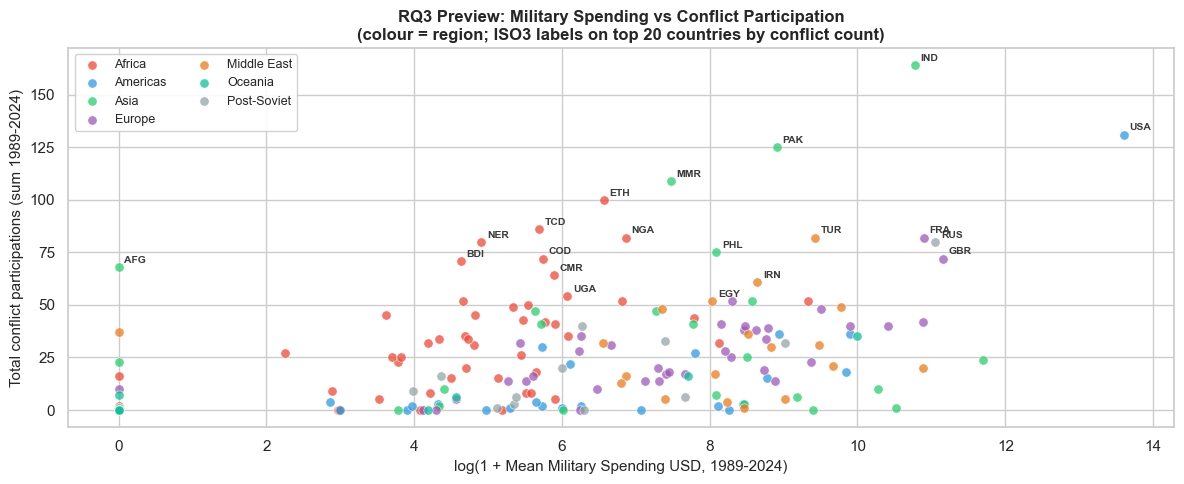

Figure saved to D:\post graduate\assignments and projects\sem 3\BDA\PeaceMakers' Arms Race\version 2\figures\eda\sec6_rq3_scatter.png


In [13]:
# ── RQ3 Preview: Military Spending vs Conflict Participation ──────────────────
# Load the cross-section panel that RQ3 clustering will operate on.
# The scatter gives an intuitive preview: high-spending states in the top right,
# peaceful small states in the bottom left.

rq3 = _load('rq3_cross_section.parquet')
if rq3 is not None:
    rq3 = rq3.copy()
    rq3['log_milex'] = np.log1p(rq3['mean_milex'].fillna(0))

    fig, ax = plt.subplots(figsize=(12, 5))

    for region, grp in rq3.groupby('region'):
        color = REGION_PAL.get(region, '#BDC3C7')
        ax.scatter(
            grp['log_milex'], grp['total_conflicts'],
            c=color, label=region,
            alpha=0.75, s=45,
            edgecolors='white', linewidth=0.5,
        )

    # Label the top 20 countries by total conflict participations
    top20 = rq3.nlargest(20, 'total_conflicts')
    for _, row in top20.iterrows():
        ax.annotate(
            row['iso3'],
            xy=(row['log_milex'], row['total_conflicts']),
            xytext=(4, 3), textcoords='offset points',
            fontsize=7.5, fontweight='bold', alpha=0.9,
        )

    ax.set_xlabel('log(1 + Mean Military Spending USD, 1989-2024)', fontsize=11)
    ax.set_ylabel('Total conflict participations (sum 1989-2024)', fontsize=11)
    ax.set_title(
        'RQ3 Preview: Military Spending vs Conflict Participation\n'
        '(colour = region; ISO3 labels on top 20 countries by conflict count)',
        fontsize=12, fontweight='bold',
    )
    ax.legend(loc='upper left', framealpha=0.9, fontsize=9, ncol=2)
    fig.tight_layout()
    fig.savefig(EDA_DIR / 'sec6_rq3_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figure saved to', EDA_DIR / 'sec6_rq3_scatter.png')
else:
    print('rq3_cross_section.parquet not found -- run NB03 first.')


---
## Section 7 — Known Data Gaps and Limitations

No dataset covering 192 countries and 79 years is complete. The gaps below are structural — they arise from political decisions by data providers (World Bank excluding Taiwan), reporting lags (UCDP coding rules), or dataset version cutoffs (CoW CINC ending at 2016). Each gap is documented here so that a reviewer can judge whether it affects the specific analysis they are scrutinising.

The most analytically significant gaps are:
- **CoW CINC cutoff (2016):** military capability cannot be controlled for post-2016, limiting some robustness checks.
- **Taiwan WDI exclusion:** Taiwan is included in the participation panel (it appears in UCDP and SIPRI data) but cannot be included in GDP-controlled regressions.

In [14]:
gaps = pd.DataFrame({
    'Country / Variable': [
        'Taiwan (TWN)',
        'Palestine (PSE)',
        'Kosovo (XKX)',
        'South Sudan (SSD)',
        'CoW CINC (all countries)',
        'Multi-country BRD rows',
    ],
    'Gap': [
        '0 WDI rows',
        'WDI data from 1994 only',
        'Pre-2008 rows attributed to SRB',
        'Pre-2011 rows attributed to SDN',
        'NaN for all years > 2016',
        '~50 conflict dyads span 2+ countries',
    ],
    'Root cause': [
        'World Bank excludes Taiwan for political reasons (PRC position in UN)',
        'Palestinian Authority data begins 1994; no pre-Oslo Accords records',
        'Kosovo declared independence Feb 2008; prior records under Serbia (SRB)',
        'South Sudan gained independence Jul 2011; prior records under Sudan (SDN)',
        'NMC v6.0 dataset ends at 2016; no subsequent v7.0 release as of 2025',
        'UCDP BRD location_inc lists multiple countries for cross-border dyads',
    ],
    'Impact on analysis': [
        'TWN in participation panel but excluded from GDP-controlled regressions',
        'PSE included from 1994; pre-1994 years have NaN GDP, zero-fill conflict counts',
        'XKX post-2008 correctly attributed; pre-2008 merged with SRB history',
        'SSD post-2011 correctly attributed; pre-2011 merged with SDN history',
        'cow_cinc NaN-preserved for 2017-2024; RQ post-2016 regressions omit CINC',
        'BRD deaths attributed to first listed country; ~50 dyads have partial coverage',
    ],
})

display(gaps.set_index('Country / Variable').style.set_table_styles([
    {'selector': 'th', 'props': [
        ('background', '#f0f0f0'), ('font-weight', 'bold'),
    ]},
    {'selector': 'td', 'props': [
        ('text-align', 'left'), ('white-space', 'normal'), ('font-size', '11px'),
    ]},
]))


,Gap,Root cause,Impact on analysis
Country / Variable,,,
Taiwan (TWN),0 WDI rows,World Bank excludes Taiwan for political reasons (PRC position in UN),TWN in participation panel but excluded from GDP-controlled regressions
Palestine (PSE),WDI data from 1994 only,Palestinian Authority data begins 1994; no pre-Oslo Accords records,"PSE included from 1994; pre-1994 years have NaN GDP, zero-fill conflict counts"
Kosovo (XKX),Pre-2008 rows attributed to SRB,Kosovo declared independence Feb 2008; prior records under Serbia (SRB),XKX post-2008 correctly attributed; pre-2008 merged with SRB history
South Sudan (SSD),Pre-2011 rows attributed to SDN,South Sudan gained independence Jul 2011; prior records under Sudan (SDN),SSD post-2011 correctly attributed; pre-2011 merged with SDN history
CoW CINC (all countries),NaN for all years > 2016,NMC v6.0 dataset ends at 2016; no subsequent v7.0 release as of 2025,cow_cinc NaN-preserved for 2017-2024; RQ post-2016 regressions omit CINC
Multi-country BRD rows,~50 conflict dyads span 2+ countries,UCDP BRD location_inc lists multiple countries for cross-border dyads,BRD deaths attributed to first listed country; ~50 dyads have partial coverage


---
## What This EDA Established

This notebook documented nine datasets from five providers, spanning 1946–2024, cleaned and merged into a balanced panel of **192 countries × 79 years (15,168 rows)**. Key findings:

1. **Scale heterogeneity** — datasets range from 1,586 rows (UCDP BRD) to 385,918 rows (UCDP GED). A log scale is always needed to compare sources.

2. **ISO3 resolution** — all nine sources share a common `iso3` key after the resolver normalised ~30 historical state names (USSR→RUS, etc.) and stripped UCDP parenthetical suffixes (e.g. 'Russia (Soviet Union)'→'RUS'). Unresolvable names (non-state actors, pre-1870 micro-states) were dropped and logged.

3. **Fill policy matters** — UCDP event counts are zero-filled (no record = zero events), while SIPRI MILEX and WDI GDP are NaN-preserved (no record = unobserved, not zero). Confusing these two silently biases regressions.

4. **Coverage gaps are structural** — CoW CINC stops in 2016, Taiwan is excluded from WDI, and multi-country BRD rows cannot be attributed to a single country. All are source-data constraints, not pipeline errors.

5. **Effective N** — only 82 of 192 countries have full 9-source coverage. The effective RQ1 regression sample (GDP + MILEX + V-Dem non-null, 1989–2024) is approximately **5,007 country-years**.

### What Comes Next

| Notebook | Task |
|----------|------|
| **NB-04** | MTS (Military Threat Signal) construction — composite indicator from MILEX, TIV, CINC and growth rates |
| **NB-05** | RQ1 regressions — panel fixed-effects models of conflict type on MTS |
| **NB-06** | RQ2 lead-lag analysis — time-series tests of arms transfers → conflict events |
| **NB-07** | RQ3 clustering — k-means + PCA on the cross-section panel |
| **NB-08** | Results synthesis and report generation |

In [15]:
# ── Raw vs Cleaned: UCDP ACD and World Bank WDI ──────────────────────────────
import sys
sys.path.insert(0, '..')

import pandas as pd
from src.config import CHECKPOINT_DIR, CLEAN_DIR
from src.io_utils import load_checkpoint
from IPython.display import display

# ── UCDP ACD ─────────────────────────────────────────────────────────────────
print("=" * 70)
print("DATASET 1: UCDP Armed Conflict Dataset (ACD)")
print("=" * 70)

acd_raw   = load_checkpoint(CHECKPOINT_DIR / "ucdp_acd_raw.parquet")
acd_clean = pd.read_parquet(CLEAN_DIR / "ucdp_acd_clean.parquet")

print(f"\nRAW   — shape: {acd_raw.shape}")
print(f"CLEAN — shape: {acd_clean.shape}")
print(f"Note: rows INCREASE because multi-country entries like 'India, Pakistan'")
print(f"      are exploded into one row per country. 3 entries remained unresolvable.\n")

print("--- RAW (first 5 rows, selected columns) ---")
display(
    acd_raw[["conflict_id", "location", "side_a", "side_b",
             "year", "type_of_conflict", "intensity_level"]]
    .head(5)
    .style.set_caption("UCDP ACD — Raw")
    .set_table_styles([{"selector": "caption",
                        "props": [("font-weight", "bold"), ("font-size", "13px")]}])
)

print("\n--- CLEAN (first 5 rows, selected columns) ---")
display(
    acd_clean[["conflict_id", "location", "iso3", "side_a",
               "year", "type_of_conflict", "intensity_level"]]
    .head(5)
    .style.set_caption("UCDP ACD — Cleaned (iso3 column added)")
    .set_table_styles([{"selector": "caption",
                        "props": [("font-weight", "bold"), ("font-size", "13px")]}])
    .map(lambda v: "background-color: #d9ead3" if v not in [None, ""]
         and str(v) != "nan" else "", subset=["iso3"])
)

# ── WORLD BANK WDI ────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("DATASET 2: World Bank World Development Indicators (WDI)")
print("=" * 70)

wdi_raw   = load_checkpoint(CHECKPOINT_DIR / "worldbank_wdi_raw.parquet")
wdi_clean = pd.read_parquet(CLEAN_DIR / "worldbank_wdi_clean.parquet")

print(f"\nRAW   — shape: {wdi_raw.shape}")
print(f"CLEAN — shape: {wdi_clean.shape}")
print(f"Dropped: {len(wdi_raw) - len(wdi_clean):,} rows")
print(f"Reason:  Regional/income-group aggregates (World, High income, East Asia")
print(f"         & Pacific, etc.) were removed — not sovereign states.\n")

dropped = wdi_raw[~wdi_raw["country"].isin(wdi_clean["country"].unique())]
print("--- DROPPED rows (sample — regional aggregates) ---")
display(
    dropped[["country", "year", "gdp_usd", "gdp_per_capita", "population"]]
    .drop_duplicates(subset=["country"])
    .head(5)
    .style.set_caption("WDI — Rows Dropped (regional aggregates, not sovereign states)")
    .set_table_styles([{"selector": "caption",
                        "props": [("font-weight", "bold"), ("font-size", "13px")]}])
    .map(lambda v: "background-color: #f4cccc", subset=["country"])
)

print("\n--- CLEAN (first 5 rows — sovereign states only) ---")
display(
    wdi_clean[["country", "iso3", "year", "gdp_usd", "gdp_per_capita", "population"]]
    .head(5)
    .style.set_caption("WDI — Cleaned (sovereign states only, iso3 added)")
    .set_table_styles([{"selector": "caption",
                        "props": [("font-weight", "bold"), ("font-size", "13px")]}])
    .map(lambda v: "background-color: #d9ead3" if v not in [None, ""]
         and str(v) != "nan" else "", subset=["iso3"])
    .format({"gdp_usd": "{:,.0f}", "gdp_per_capita": "{:,.0f}",
             "population": "{:,.0f}"}, na_rep="NaN")
)

print("\nSummary:")
print(f"  WDI raw:   {len(wdi_raw):>6,} rows | {wdi_raw['country'].nunique()} unique countries (incl. aggregates)")
print(f"  WDI clean: {len(wdi_clean):>6,} rows | {wdi_clean['iso3'].nunique()} unique ISO3 codes (sovereign only)")

DATASET 1: UCDP Armed Conflict Dataset (ACD)
[checkpoint] loaded ← ucdp_acd_raw.parquet  (2,752 rows)

RAW   — shape: (2752, 28)
CLEAN — shape: (2917, 30)
Note: rows INCREASE because multi-country entries like 'India, Pakistan'
      are exploded into one row per country. 3 entries remained unresolvable.

--- RAW (first 5 rows, selected columns) ---


,conflict_id,location,side_a,side_b,year,type_of_conflict,intensity_level
0,11342,India,Government of India,GNLA,2012,3,1
1,11342,India,Government of India,GNLA,2014,3,1
2,11343,"Egypt, Israel",Government of Egypt,Government of Israel,1967,2,2
3,11343,"Egypt, Israel",Government of Egypt,Government of Israel,1969,2,1
4,11343,"Egypt, Israel",Government of Egypt,Government of Israel,1970,2,1



--- CLEAN (first 5 rows, selected columns) ---


,conflict_id,location,iso3,side_a,year,type_of_conflict,intensity_level
0,11342,India,IND,Government of India,2012,3,1
1,11342,India,IND,Government of India,2014,3,1
2,11343,"Egypt, Israel",EGY,Government of Egypt,1967,2,2
3,11343,"Egypt, Israel",ISR,Government of Egypt,1967,2,2
4,11343,"Egypt, Israel",EGY,Government of Egypt,1969,2,1



DATASET 2: World Bank World Development Indicators (WDI)
[checkpoint] loaded ← worldbank_wdi_raw.parquet  (17,195 rows)

RAW   — shape: (17195, 5)
CLEAN — shape: (13035, 6)
Dropped: 4,160 rows
Reason:  Regional/income-group aggregates (World, High income, East Asia
         & Pacific, etc.) were removed — not sovereign states.

--- DROPPED rows (sample — regional aggregates) ---


,country,year,gdp_usd,gdp_per_capita,population
65,Africa Eastern and Southern,1960,24205688712.375900,186.089204,130075728.000000
130,Africa Western and Central,1960,11904805741.683100,121.936832,97630925.000000
585,Arab World,1960,nan,nan,91540853.000000
2535,Caribbean small states,1960,1165303060.286890,455.490442,2558348.000000
2730,Central Europe and the Baltics,1960,nan,nan,91401309.000000



--- CLEAN (first 5 rows — sovereign states only) ---


,country,iso3,year,gdp_usd,gdp_per_capita,population
0,Afghanistan,AFG,1960,NaN,NaN,"9,035,043"
1,Afghanistan,AFG,1961,NaN,NaN,"9,214,083"
2,Afghanistan,AFG,1962,NaN,NaN,"9,404,406"
3,Afghanistan,AFG,1963,NaN,NaN,"9,604,487"
4,Afghanistan,AFG,1964,NaN,NaN,"9,814,318"



Summary:
  WDI raw:   17,195 rows | 265 unique countries (incl. aggregates)
  WDI clean: 13,035 rows | 201 unique ISO3 codes (sovereign only)


In [16]:
ucdp_acd_clean      = pd.read_parquet(CLEAN_DIR / "ucdp_acd_clean.parquet")
ucdp_ged_clean      = pd.read_parquet(CLEAN_DIR / "ucdp_ged_clean.parquet")
ucdp_brd_clean      = pd.read_parquet(CLEAN_DIR / "ucdp_brd_clean.parquet")
ucdp_dyadic_clean   = pd.read_parquet(CLEAN_DIR / "ucdp_dyadic_clean.parquet")
sipri_milex_clean   = pd.read_parquet(CLEAN_DIR / "sipri_milex_clean.parquet")
sipri_tiv_clean     = pd.read_parquet(CLEAN_DIR / "sipri_tiv_by_country_year_clean.parquet")
worldbank_wdi_clean = pd.read_parquet(CLEAN_DIR / "worldbank_wdi_clean.parquet")
vdem_clean          = pd.read_parquet(CLEAN_DIR / "vdem_clean.parquet")
cow_cinc_clean      = pd.read_parquet(CLEAN_DIR / "cow_cinc_clean.parquet")

for name, df in [
    ("ucdp_acd",    ucdp_acd_clean),
    ("ucdp_ged",    ucdp_ged_clean),
    ("ucdp_brd",    ucdp_brd_clean),
    ("ucdp_dyadic", ucdp_dyadic_clean),
    ("sipri_milex", sipri_milex_clean),
    ("sipri_tiv",   sipri_tiv_clean),
    ("worldbank_wdi", worldbank_wdi_clean),
    ("vdem",        vdem_clean),
    ("cow_cinc",    cow_cinc_clean),
]:
    print(f"  loaded {name}_clean  {df.shape}")


  loaded ucdp_acd_clean  (2917, 30)
  loaded ucdp_ged_clean  (385918, 51)
  loaded ucdp_brd_clean  (1586, 26)
  loaded ucdp_dyadic_clean  (3432, 30)
  loaded sipri_milex_clean  (8362, 4)
  loaded sipri_tiv_clean  (7845, 3)
  loaded worldbank_wdi_clean  (13035, 6)
  loaded vdem_clean  (12787, 5)
  loaded cow_cinc_clean  (15166, 6)


In [17]:
print(f"master_panel: {master.shape}\n")
display(master.head(10))
display(master.describe(include='all').T)


master_panel: (15168, 61)



,iso3,year,acd_n_conflicts,acd_n_war,acd_n_minor,acd_n_interstate,acd_n_intrastate,acd_n_extrasystemic,acd_n_internationalised,part_n_conflicts,part_n_interstate,part_n_intrastate,part_n_internationalised,part_n_extrasystemic,part_n_war,part_n_minor,part_n_extraterritorial,brd_deaths_best,brd_deaths_low,brd_deaths_high,ged_n_events,ged_deaths_total,sipri_milex_const2024_usd,tiv_imports_total,tiv_cat_air_defence_systems,tiv_cat_aircraft,tiv_cat_armoured_vehicles,tiv_cat_artillery,tiv_cat_engines,tiv_cat_missiles,...,tiv_cat_other,tiv_cat_satellites,tiv_cat_sensors,tiv_cat_ships,wb_gdp_usd,wb_gdp_per_capita,wb_population,vdem_v2x_polyarchy,cow_cinc,cow_milper,cow_milex,has_military,log_milex,log_tiv_imports,log_gdp,log_pop,war_minor_ratio,milex_pct_gdp,extraterritorial_share,tiv_imports_5yr_sum,milex_5yr_mean,era_cold_war,era_post_cw,era_post_911,region,mts_milex,mts_tiv,mts_pca,mts_pca_3feat,tiv_ever_imported
0,AFG,1946,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.089,0.002501,90.0,0.0,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,0.0,NaN,True,False,False,Asia,NaN,NaN,NaN,NaN,0.0
1,AFG,1947,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.089,0.002474,100.0,0.0,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,0.0,NaN,True,False,False,Asia,NaN,NaN,NaN,NaN,0.0
2,AFG,1948,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.089,0.002334,90.0,0.0,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,0.0,NaN,True,False,False,Asia,NaN,NaN,NaN,NaN,0.0
3,AFG,1949,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.093,0.001979,75.0,0.0,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,0.0,NaN,True,False,False,Asia,NaN,NaN,NaN,NaN,0.0
4,AFG,1950,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.099,0.001606,75.0,4654.0,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,0.0,NaN,True,False,False,Asia,NaN,NaN,NaN,NaN,0.0
5,AFG,1951,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.099,0.001405,60.0,5657.0,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,0.0,NaN,True,False,False,Asia,NaN,NaN,NaN,NaN,0.0
6,AFG,1952,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.088,0.001331,60.0,6730.0,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,0.0,NaN,True,False,False,Asia,NaN,NaN,NaN,NaN,0.0
7,AFG,1953,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.085,0.001181,41.0,9596.0,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,0.0,NaN,True,False,False,Asia,NaN,NaN,NaN,NaN,0.0
8,AFG,1954,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.079,0.001156,41.0,5012.0,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,0.0,NaN,True,False,False,Asia,NaN,NaN,NaN,NaN,0.0
9,AFG,1955,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,4.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.080,0.001155,43.0,6504.0,NaN,NaN,1.609438,NaN,NaN,NaN,NaN,NaN,4.0,NaN,True,False,False,Asia,NaN,0.159339,NaN,NaN,1.0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
iso3,15168,192,AFG,79,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,15168.0,NaN,NaN,NaN,1985.0,22.80426,1946.0,1965.0,1985.0,2005.0,2024.0
acd_n_conflicts,15168.0,NaN,NaN,NaN,0.191258,0.594039,0.0,0.0,0.0,0.0,7.0
acd_n_war,15168.0,NaN,NaN,NaN,0.04938,0.243869,0.0,0.0,0.0,0.0,3.0
acd_n_minor,15168.0,NaN,NaN,NaN,0.142735,0.501332,0.0,0.0,0.0,0.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...
mts_milex,8212.0,NaN,NaN,NaN,0.480463,0.179304,0.0,0.351966,0.490612,0.609262,1.0
mts_tiv,9771.0,NaN,NaN,NaN,0.502903,0.233095,0.0,0.323625,0.513137,0.698176,1.0
mts_pca,6250.0,NaN,NaN,NaN,0.411149,0.184473,0.0,0.261538,0.40988,0.555164,1.0
mts_pca_3feat,7550.0,NaN,NaN,NaN,0.249153,0.122839,0.0,0.144492,0.245578,0.347999,1.0


In [18]:
n_iso3_unique = master["iso3"].nunique()
n_year_unique = master["year"].nunique()

balanced = n_iso3_unique * n_year_unique == master.shape[0]
print(f"Balanced panel check: {balanced}")

n_rq1 = master[
    master["wb_gdp_usd"].notna() &
    master["sipri_milex_const2024_usd"].notna() &
    master["vdem_v2x_polyarchy"].notna() &
    (master["year"] >= 1989)
].shape[0]
print(f"Effective RQ1 sample: {n_rq1:,} country-years")


Balanced panel check: True
Effective RQ1 sample: 5,007 country-years


In [19]:
from scipy.stats import spearmanr

rq1 = _load('rq1_panel.parquet')

features = ["log_milex", "log_tiv_imports", "log_gdp", "vdem_v2x_polyarchy"]

print(f"{'Feature':<25}  {'minor':>8}  {'war':>8}  {'n':>6}")
print("-" * 55)
for feat in features:
    subset = rq1[[feat, "part_n_minor", "part_n_war"]].dropna()
    rho_minor, _ = spearmanr(subset[feat], subset["part_n_minor"])
    rho_war,   _ = spearmanr(subset[feat], subset["part_n_war"])
    print(f"{feat:<25}  {rho_minor:>8.3f}  {rho_war:>8.3f}  {len(subset):>6,}")


  loaded rq1_panel.parquet  (6912, 23)
Feature                       minor       war       n
-------------------------------------------------------
log_milex                     0.220     0.200   5,228
log_tiv_imports               0.277     0.226   6,912
log_gdp                       0.322     0.258   6,548
vdem_v2x_polyarchy            0.007     0.065   6,207


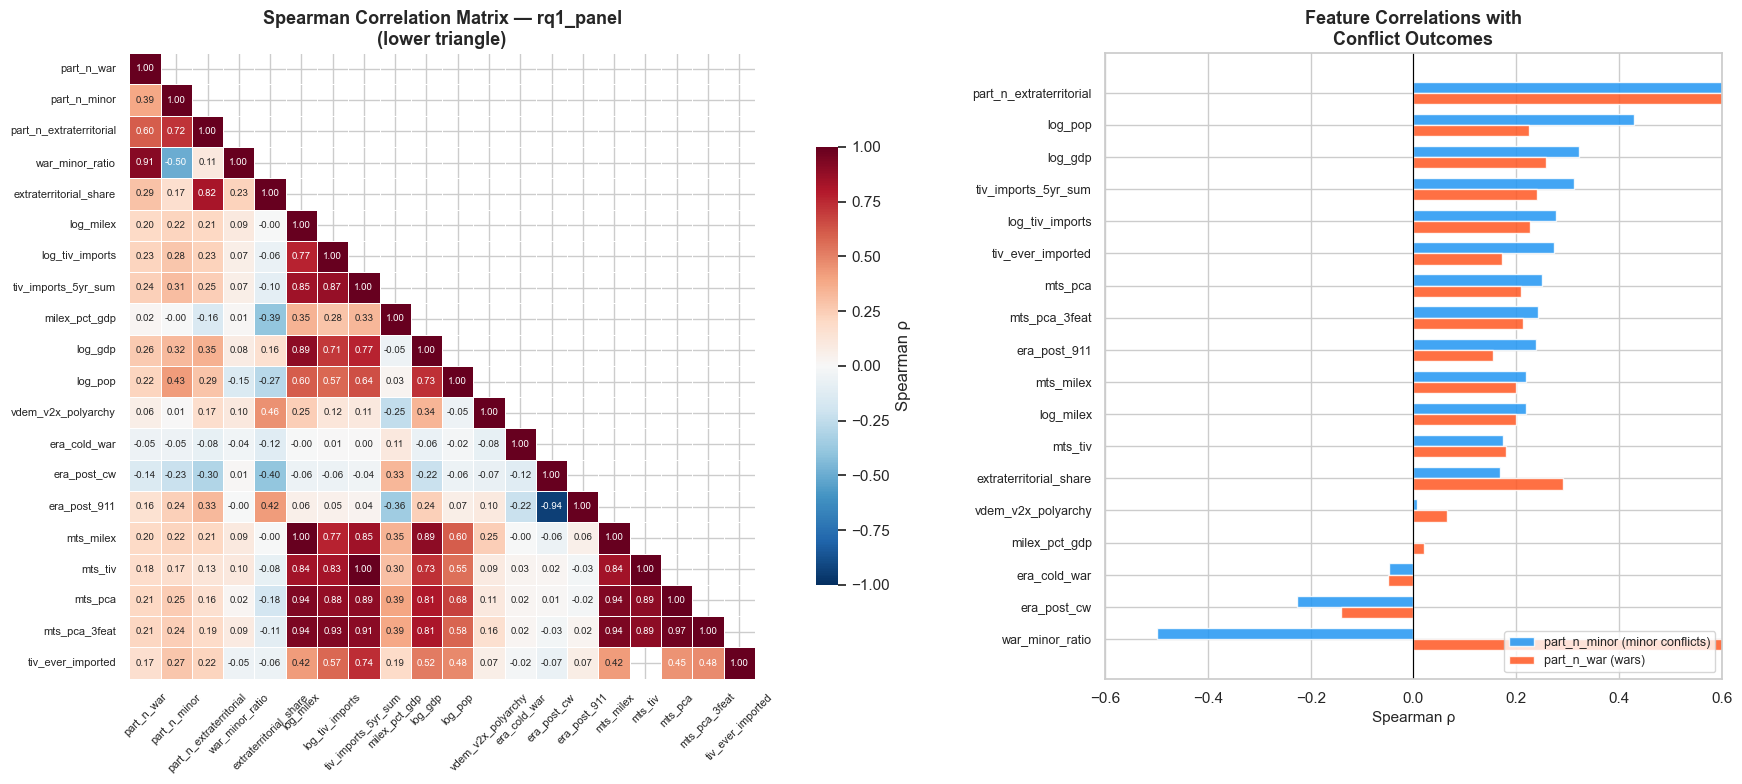

Figure saved to D:\post graduate\assignments and projects\sem 3\BDA\PeaceMakers' Arms Race\version 2\figures\eda\sec8_spearman_heatmap.png


In [20]:
# ── Spearman correlation heatmap + outcome bar chart ─────────────────────────
numeric_cols  = [c for c in rq1.columns if c not in ('iso3', 'year', 'region')]
outcome_cols  = ['part_n_minor', 'part_n_war']
feature_cols  = [c for c in numeric_cols if c not in outcome_cols]

spearman_corr = rq1[numeric_cols].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(20, 8),
                         gridspec_kw={'width_ratios': [2, 1]})

# ── Left: full Spearman heatmap (lower triangle) ──────────────────────────────
mask = np.triu(np.ones_like(spearman_corr, dtype=bool), k=1)  # hide upper triangle
sns.heatmap(
    spearman_corr,
    mask=mask,
    ax=axes[0],
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    linewidths=0.4, square=True,
    cbar_kws={'shrink': 0.7, 'label': 'Spearman ρ'},
)
axes[0].set_title('Spearman Correlation Matrix — rq1_panel\n(lower triangle)',
                  fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', rotation=0,  labelsize=8)

# ── Right: bar chart — features vs the two outcome columns ────────────────────
rho_df = spearman_corr.loc[feature_cols, outcome_cols].sort_values('part_n_minor')

y      = np.arange(len(rho_df))
height = 0.35

axes[1].barh(y + height / 2, rho_df['part_n_minor'], height,
             label='part_n_minor (minor conflicts)', color='#2196F3', alpha=0.85)
axes[1].barh(y - height / 2, rho_df['part_n_war'],   height,
             label='part_n_war (wars)',              color='#FF5722', alpha=0.85)

axes[1].set_yticks(y)
axes[1].set_yticklabels(rho_df.index, fontsize=9)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Spearman ρ', fontsize=11)
axes[1].set_title('Feature Correlations with\nConflict Outcomes',
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9, loc='lower right')
axes[1].set_xlim(-0.6, 0.6)

fig.tight_layout()
fig.savefig(EDA_DIR / 'sec8_spearman_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to', EDA_DIR / 'sec8_spearman_heatmap.png')


In [21]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca_features = ["log_milex", "log_tiv_imports", "cow_cinc", "milex_pct_gdp"]
X = StandardScaler().fit_transform(master[pca_features].dropna())
pca = PCA(n_components=1).fit(X)
print("PCA Loadings (PC1):")
for name, loading in zip(pca_features, pca.components_[0]):
    print(f"  {name:<25} {loading:.4f}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_[0]:.3f}")


PCA Loadings (PC1):
  log_milex                 0.6220
  log_tiv_imports           0.5833
  cow_cinc                  0.4635
  milex_pct_gdp             0.2410
Explained variance ratio: 0.535


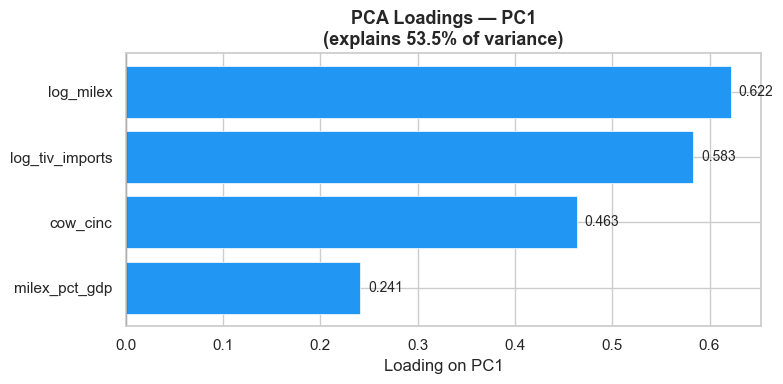

Figure saved to D:\post graduate\assignments and projects\sem 3\BDA\PeaceMakers' Arms Race\version 2\figures\eda\sec9_pca_loadings.png


In [22]:
# ── PCA PC1 loadings bar chart ────────────────────────────────────────────────
loadings = pca.components_[0].copy()

# PC1 sign is arbitrary — flip so log_milex (the primary treatment variable) is positive
if loadings[pca_features.index("log_milex")] < 0:
    loadings = -loadings

load_series = pd.Series(loadings, index=pca_features).sort_values()
colors = ['#2196F3' if v >= 0 else '#FF5722' for v in load_series]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(load_series.index, load_series.values,
               color=colors, edgecolor='white', linewidth=0.5)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Loading on PC1', fontsize=12)
ax.set_title(
    f'PCA Loadings — PC1\n(explains {pca.explained_variance_ratio_[0]:.1%} of variance)',
    fontsize=13, fontweight='bold',
)

for val, bar in zip(load_series.values, bars):
    offset = 0.008 if val >= 0 else -0.008
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=10)

fig.tight_layout()
fig.savefig(EDA_DIR / 'sec9_pca_loadings.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to', EDA_DIR / 'sec9_pca_loadings.png')


In [23]:
import statsmodels.formula.api as smf

formula = "part_n_minor ~ log_milex + log_gdp + vdem_v2x_polyarchy + C(iso3) + C(year)"
model = smf.ols(formula, data=rq1.dropna(subset=[
    "part_n_minor", "log_milex", "log_gdp", "vdem_v2x_polyarchy"
])).fit(cov_type="HC3")

key_vars = [v for v in model.params.index
            if not v.startswith('C(iso3)') and not v.startswith('C(year)')]

summary_df = pd.DataFrame({
    'coef':    model.params[key_vars],
    'std err': model.bse[key_vars],
    't':       model.tvalues[key_vars],
    'P>|t|':   model.pvalues[key_vars],
    '[0.025':  model.conf_int().loc[key_vars, 0],
    '0.975]':  model.conf_int().loc[key_vars, 1],
})

print(f"OLS with two-way FE: part_n_minor ~ treatment vars + C(iso3) + C(year)")
print(f"N={int(model.nobs):,}  R²={model.rsquared:.4f}  Adj-R²={model.rsquared_adj:.4f}  (HC3 SEs)\n")
display(summary_df.style
    .format("{:.4f}")
    .map(lambda v: "font-weight: bold; color: #1a5276"
         if isinstance(v, float) and v < 0.05 else "", subset=["P>|t|"])
)


OLS with two-way FE: part_n_minor ~ treatment vars + C(iso3) + C(year)
N=5,007  R²=0.4889  Adj-R²=0.4686  (HC3 SEs)



,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,2.3881,1.3362,1.7872,0.0739,-0.2308,5.0071
log_milex,0.2501,0.0382,6.5436,0.0000,0.1752,0.3250
log_gdp,-0.1591,0.0575,-2.7677,0.0056,-0.2718,-0.0464
vdem_v2x_polyarchy,0.5260,0.2148,2.4484,0.0143,0.1049,0.9471


In [24]:
cols = [
    'part_n_war', 'part_n_minor', 'war_minor_ratio',
    'sipri_milex_const2024_usd', 'vdem_v2x_polyarchy', 'wb_gdp_usd',
]

desc = master[cols].describe().T
desc.insert(0, 'non-null', master[cols].notna().sum())

display(
    desc.style
    .format({
        'count':    '{:,.0f}',
        'non-null': '{:,.0f}',
        'mean':     '{:,.4f}',
        'std':      '{:,.4f}',
        'min':      '{:,.4f}',
        '25%':      '{:,.4f}',
        '50%':      '{:,.4f}',
        '75%':      '{:,.4f}',
        'max':      '{:,.4f}',
    })
    .set_caption('Master Panel — Descriptive Statistics (N = 15,168 country-years)')
    .set_table_styles([
        {'selector': 'caption', 'props': [
            ('font-size', '14px'), ('font-weight', 'bold'), ('text-align', 'left'),
        ]},
        {'selector': 'th', 'props': [
            ('background', '#f0f0f0'), ('font-weight', 'bold'),
        ]},
        {'selector': 'td', 'props': [('text-align', 'right')]},
    ])
    .highlight_null(color='#ffe0e0')
)


,non-null,count,mean,std,min,25%,50%,75%,max
part_n_war,"15,168","15,168",0.1415,0.4679,0.0000,0.0000,0.0000,0.0000,6.0000
part_n_minor,"15,168","15,168",0.3961,1.0535,0.0000,0.0000,0.0000,0.0000,11.0000
war_minor_ratio,"3,502","3,502",0.3096,0.3897,0.0000,0.0000,0.0000,0.5000,1.0000
sipri_milex_const2024_usd,"8,212","8,212","12,325.7718","69,936.2700",0.0000,131.1127,903.5272,"4,691.5362","1,061,674.3327"
vdem_v2x_polyarchy,"12,707","12,707",0.3920,0.2870,0.0070,0.1480,0.2990,0.6605,0.9220
wb_gdp_usd,"10,369","10,369","210,233,549,157.2563","1,149,890,127,778.9980","2,585,955.8741","1,706,190,450.0000","9,514,404,016.2095","58,847,019,609.6549","28,750,956,130,731.1992"


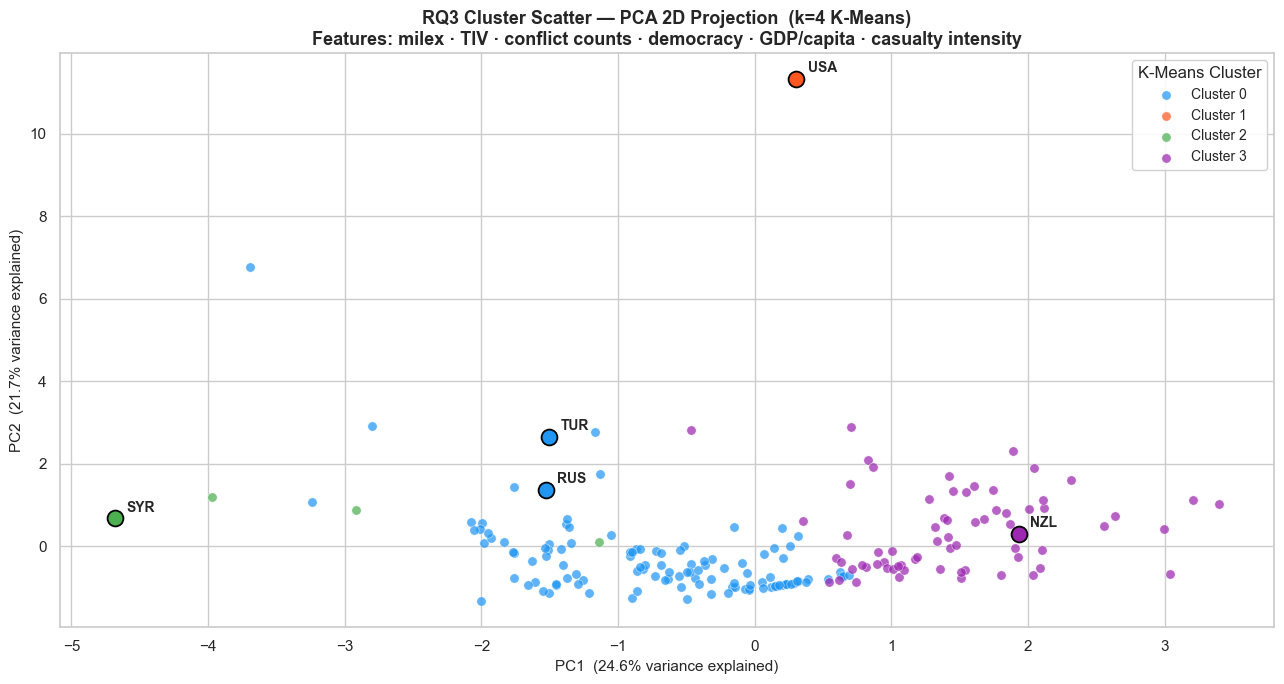

Figure saved to D:\post graduate\assignments and projects\sem 3\BDA\PeaceMakers' Arms Race\version 2\figures\eda\sec10_rq3_cluster_scatter.png


In [25]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

CLUSTER_FEATURES = [
    'mean_milex', 'mean_tiv', 'total_conflicts',
    'mean_war_minor_ratio', 'mean_extraterritorial_share',
    'mean_polyarchy', 'mean_gdp_per_capita', 'casualty_intensity',
]
LABEL_COUNTRIES = {'USA', 'RUS', 'SYR', 'TUR', 'NZL'}
CLUSTER_PAL     = {0: '#2196F3', 1: '#FF5722', 2: '#4CAF50', 3: '#9C27B0'}

# Median-impute before scaling so NaN countries (e.g. AFG missing milex) are kept
rq3_cl = rq3.copy()
for col in CLUSTER_FEATURES:
    rq3_cl[col] = rq3_cl[col].fillna(rq3_cl[col].median())

X_scaled = StandardScaler().fit_transform(rq3_cl[CLUSTER_FEATURES])

# PCA → 2D projection
pca2   = PCA(n_components=2, random_state=42)
coords = pca2.fit_transform(X_scaled)
rq3_cl['PC1'] = coords[:, 0]
rq3_cl['PC2'] = coords[:, 1]

# K-Means (k=4 matches the four geopolitical profiles expected under SIP)
km = KMeans(n_clusters=4, random_state=42, n_init=10)
rq3_cl['cluster'] = km.fit_predict(X_scaled)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 7))

for cid, grp in rq3_cl.groupby('cluster'):
    ax.scatter(grp['PC1'], grp['PC2'],
               c=CLUSTER_PAL[cid], label=f'Cluster {cid}',
               alpha=0.72, s=45, edgecolors='white', linewidth=0.4)

# Highlighted + labelled key countries
for _, row in rq3_cl[rq3_cl['iso3'].isin(LABEL_COUNTRIES)].iterrows():
    ax.scatter(row['PC1'], row['PC2'],
               c=CLUSTER_PAL[row['cluster']], s=130,
               edgecolors='black', linewidth=1.3, zorder=5)
    ax.annotate(
        row['iso3'],
        xy=(row['PC1'], row['PC2']),
        xytext=(8, 5), textcoords='offset points',
        fontsize=10, fontweight='bold',
        arrowprops=dict(arrowstyle='-', color='#555', lw=0.8),
    )

ax.set_xlabel(f"PC1  ({pca2.explained_variance_ratio_[0]:.1%} variance explained)", fontsize=11)
ax.set_ylabel(f"PC2  ({pca2.explained_variance_ratio_[1]:.1%} variance explained)", fontsize=11)
ax.set_title(
    'RQ3 Cluster Scatter — PCA 2D Projection  (k=4 K-Means)\n'
    'Features: milex · TIV · conflict counts · democracy · GDP/capita · casualty intensity',
    fontsize=13, fontweight='bold',
)
ax.legend(title='K-Means Cluster', framealpha=0.9, fontsize=10)
fig.tight_layout()
fig.savefig(EDA_DIR / 'sec10_rq3_cluster_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to', EDA_DIR / 'sec10_rq3_cluster_scatter.png')


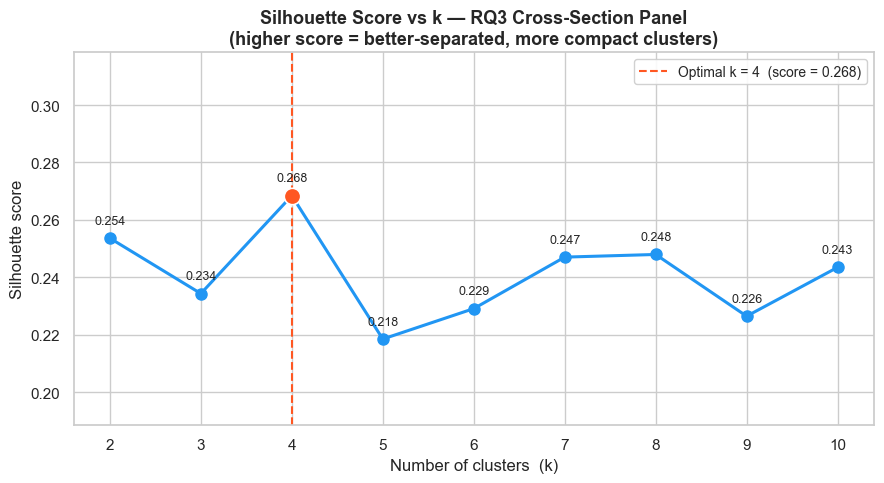

Optimal k = 4  (silhouette = 0.268)


In [26]:
from sklearn.metrics import silhouette_score

k_range    = range(2, 11)
sil_scores = [
    silhouette_score(
        X_scaled,
        KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)
    )
    for k in k_range
]

best_k     = list(k_range)[int(np.argmax(sil_scores))]
best_score = max(sil_scores)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(list(k_range), sil_scores,
        marker='o', color='#2196F3', linewidth=2.2, markersize=8, zorder=3)

ax.axvline(best_k, color='#FF5722', linestyle='--', linewidth=1.5,
           label=f'Optimal k = {best_k}  (score = {best_score:.3f})')
ax.scatter([best_k], [best_score],
           color='#FF5722', s=140, zorder=5, edgecolors='white', linewidth=1.2)

for k, score in zip(k_range, sil_scores):
    ax.text(k, score + 0.004, f'{score:.3f}',
            ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Number of clusters  (k)', fontsize=12)
ax.set_ylabel('Silhouette score', fontsize=12)
ax.set_title(
    'Silhouette Score vs k — RQ3 Cross-Section Panel\n'
    '(higher score = better-separated, more compact clusters)',
    fontsize=13, fontweight='bold',
)
ax.set_xticks(list(k_range))
ax.set_ylim(min(sil_scores) - 0.03, max(sil_scores) + 0.05)
ax.legend(fontsize=10, framealpha=0.9)

fig.tight_layout()
fig.savefig(EDA_DIR / 'sec10_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Optimal k = {best_k}  (silhouette = {best_score:.3f})')
